# Peak tracker: click a spot, see how it moves across the raster

**Model-free, no indexing.** `midas_defect.peak_tracker` does not use `hkl`, a cell, or a
domain at all -- it tracks a peak's DETECTOR position (row, col, frame/omega), width, and
intensity by flood-filling outward from a seed pixel across the raster's grid neighbors,
re-centering a small search window at each step from the *previous step's own centroid*
(not a single static window from the original seed -- see the re-centering demo below).
That sidesteps any hkl-indexing artifact entirely: no cell is fitted here, so there is
nothing for one to bias.

Why detector-space tracking rather than `hkl` matching: each raster position's crystal
domain has its own orientation, so "the (2,0,2) reflection" at two different positions is
not necessarily the same physical plane unless the domains happen to share orientation.
Neighboring raster POSITIONS, though, very likely share the same physical grain with only a
slowly drifting orientation -- so a peak's pixel trajectory moving smoothly from one raster
point to its neighbor is a model-free way to see that drift directly, before any indexing.

**Three-state result, not a binary tracked/not-tracked.** Every position ends in one of three
states (`midas_defect.peak_tracker.STATUS_*`):

- `STATUS_TRACKED` -- accepted and propagated onward.
- `STATUS_REJECTED` -- a peak candidate WAS found here, but its jump from the previous step
  (position or intensity) was too large to trust as a continuation of the same physical
  reflection -- likely the search window locked onto a different, unrelated bright peak
  (a "hijack"). Its real, measured values are still recorded, not thrown away -- only the
  *propagation* stops, so you can see "something is here, but it doesn't connect smoothly"
  rather than a blank that reads identically to "nothing is here".
- `STATUS_NO_SIGNAL` -- no peak found above the SNR floor at all.

This notebook runs entirely on synthetic data so it works with no beamline connection. For a
real deployment against actual detector frames on a remote host (only the `loader` callable
changes), see e.g. the nickelate DAC project's `run_track_full.py`, which imports these same
`midas_defect.peak_tracker` functions.


In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

from midas_defect.peak_tracker import (
    windowed_centroid, track_peak_over_raster, snap_to_local_max, plot_peak_maps,
)

RNG = np.random.default_rng(20260913)
N_ROWS, N_COLS = 9, 9      # a small synthetic raster
NF, NR, NC = 9, 80, 80     # frames, detector rows, detector cols per position
BG = 100.0


def _blank():
    return RNG.normal(BG, 1.5, size=(NF, NR, NC))


def _plant(frames, row, col, frame, amp, half=1):
    f0, f1 = frame - half, frame + half + 1
    r0, r1 = row - half, row + half + 1
    c0, c1 = col - half, col + half + 1
    frames = frames.copy()
    frames[f0:f1, r0:r1, c0:c1] += amp
    return frames


def loader(p):
    """Position p's frame stack: two peaks. Peak A drifts smoothly (a real grain's mosaic
    tilt); peak B (the 'decoy') sits at a fixed detector position that peak A's search window
    will eventually sweep past, standing in for an unrelated bright reflection nearby.
    """
    r, c = divmod(p, N_COLS)
    frames = _blank()
    row_a = 20 + 3 * r
    col_a = 15 + 3 * c
    frames = _plant(frames, row=row_a, col=col_a, frame=4, amp=4000.0)
    frames = _plant(frames, row=55, col=55, frame=4, amp=9000.0)  # fixed decoy, bright
    return frames


# reference: max-over-frames projection at the raster's geometric center, for picking a seed
REF_POINT = (N_ROWS // 2) * N_COLS + (N_COLS // 2)
proj_ref = loader(REF_POINT).max(axis=0)
print(f"reference: point {REF_POINT}, raster {N_ROWS}x{N_COLS}, frame shape {proj_ref.shape}")


reference: point 40, raster 9x9, frame shape (80, 80)


## Click a peak on the reference image

Click anywhere near a bright spot below. The click snaps to the nearest real local maximum
within a small radius (`snap_to_local_max` -- clicking precisely on a 1-pixel spot is
unrealistic), reads off that pixel's own brightest frame as the omega seed, then runs the
full-raster tracker and plots the result.

Try clicking the fainter, steadily-drifting spot near the middle first (peak A -- it should
track cleanly across the whole raster), then try one whose search window will sweep across
the fixed bright decoy in a corner as the raster position changes, to see a `STATUS_REJECTED`
row/column show up as red-outlined squares in the maps below instead of a silent gap.


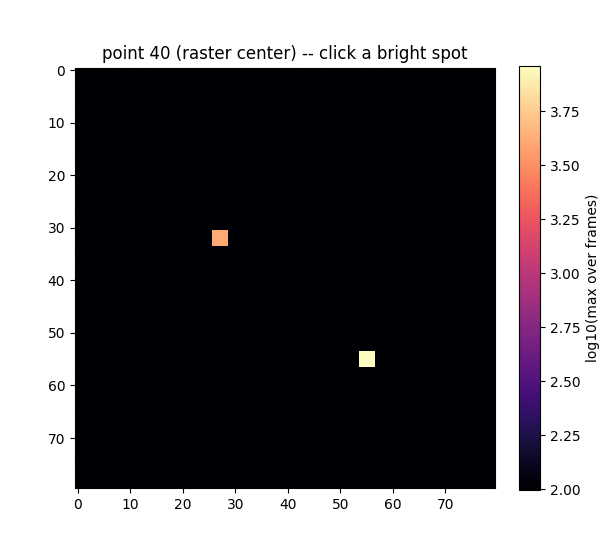

In [2]:
def onclick(event):
    if event.xdata is None or event.ydata is None:
        return
    col, row = int(round(event.xdata)), int(round(event.ydata))
    row, col = snap_to_local_max(proj_ref, row, col, radius=10)
    frame_guess = int(np.argmax(loader(REF_POINT)[:, row, col]))
    print(f"picked pixel -> snapped to local max (row={row}, col={col}), "
         f"brightest frame={frame_guess}, peak value={proj_ref[row, col]:.0f}")
    ax_img.plot([col], [row], "r+", ms=16, mew=2)
    fig.canvas.draw_idle()

    grids = track_peak_over_raster(loader, N_ROWS, N_COLS, REF_POINT, row, col, frame_guess,
                                   win_rc=10, win_f=3, log=lambda *a, **k: None)
    plot_peak_maps(grids, title_prefix=f"picked at (row={row}, col={col}): ",
                  cmap=CMAP_PICKER.value if 'CMAP_PICKER' in globals() else "viridis")


fig, ax_img = plt.subplots(figsize=(6, 5.5))
im = ax_img.imshow(np.log10(np.clip(proj_ref, 1, None)), cmap="magma")
plt.colorbar(im, ax=ax_img, fraction=0.046, label="log10(max over frames)")
ax_img.set_title(f"point {REF_POINT} (raster center) -- click a bright spot")
fig.canvas.mpl_connect("button_press_event", onclick)
plt.show()


## Colormap picker + more panels

`plot_peak_maps` takes `cmap` (any matplotlib colormap name) and `fields` (which panels to
draw, in order -- any subset of `centroid_row`, `centroid_col`, `centroid_frame`,
`intensity`, `sigma_row`, `sigma_col`, `sigma_frame`, `peak_max`, `background`).

If `ipywidgets` is available, the dropdown below re-plots a pre-tracked result live as you
change the colormap, without re-running the tracker. Otherwise, just pass `cmap=` directly to
`plot_peak_maps` in a plain cell (also shown below).


In [3]:
# track peak A once from its known position so this section has something to show immediately
demo_grids = track_peak_over_raster(loader, N_ROWS, N_COLS, REF_POINT,
                                    seed_row=20 + 3 * (N_ROWS // 2), seed_col=15 + 3 * (N_COLS // 2),
                                    seed_frame=4, win_rc=10, win_f=3, log=lambda *a, **k: None)

try:
    import ipywidgets as w
    from IPython.display import display

    CMAP_PICKER = w.Dropdown(options=["viridis", "plasma", "coolwarm", "magma", "cividis"],
                             value="viridis", description="cmap:")
    FIELD_PICKER = w.SelectMultiple(
        options=["centroid_row", "centroid_col", "centroid_frame", "intensity",
                "sigma_row", "sigma_col", "sigma_frame", "peak_max", "background"],
        value=["centroid_row", "centroid_col", "sigma_row", "sigma_col", "intensity", "peak_max"],
        description="panels:", rows=9)
    out = w.Output()

    def _redraw(*_):
        with out:
            out.clear_output(wait=True)
            plot_peak_maps(demo_grids, cmap=CMAP_PICKER.value, fields=tuple(FIELD_PICKER.value))

    CMAP_PICKER.observe(_redraw, names="value")
    FIELD_PICKER.observe(_redraw, names="value")
    display(w.HBox([CMAP_PICKER, FIELD_PICKER]), out)
    _redraw()
except ImportError:
    print("ipywidgets not available -- pass cmap=/fields= directly:")
    plot_peak_maps(demo_grids, cmap="plasma",
                   fields=("centroid_row", "centroid_col", "sigma_row", "sigma_col",
                          "intensity", "peak_max"))


Output()

## Reading the maps

- **centroid_row / centroid_col**: the peak's own sub-pixel detector position at each raster
  point. A smooth spatial gradient here is a real, model-free signature of a rotating/tilting
  lattice (mosaic curvature) across the raster -- no indexing needed to see it.
- **centroid_frame**: which omega step the peak sits at -- a drift here is an orientation
  change about an axis roughly parallel to the rotation axis.
- **intensity**: falls off (status leaves `STATUS_TRACKED`) at a grain boundary or wherever
  this reflection is no longer near its Bragg condition.
- **sigma_row / sigma_col / sigma_frame**: peak width -- broadening can indicate strain
  gradients or increasing mosaicity, but a width this close to the instrument's own
  resolution is a LOWER BOUND, not a measurement, until checked against a resolution-limited
  control peak.
- **Blank (gray) pixels are `STATUS_NO_SIGNAL`** -- the flood-fill refuses to propagate a
  centroid past a position where it lost the peak; a hole here says "not this peak, here"
  rather than guessing.
- **Red-outlined pixels are `STATUS_REJECTED`** -- a candidate peak was found and its value is
  plotted, but the walk did not trust it as a continuation (too large a jump in position or
  intensity from the previous step) and stopped propagating from there. This is the state that
  used to be indistinguishable from a blank -- it is not a gap to fill in, and it is not the
  same claim as "nothing is here" either.
